# 02 · ML Pipeline Hands-On (MLP, 3 Oct 2026)

Companion notebook for `02-ML-Pipeline-Hands-On.md`. Re-creates the professor's demo:

1. **Part A:** Sentiment classification with hand-crafted features (word / noun / verb count) + Logistic Regression
2. **Part B:** Iris flower classification (scikit-learn built-in dataset)
3. **Part C:** Homework: `load_digits` (try it yourself first)
4. **Part D:** Extras: random seed, Pearson correlation for feature selection

> The professor's test reviews were not in the slides, so Part A uses my own 5 test reviews. Your numbers will differ from the class (class result: 20% accuracy).

## Part A — Sentiment pipeline
### Step 1: Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import nltk
from nltk import pos_tag, word_tokenize

In [2]:
# Download the tokenizer and the English POS tagger (needed once per environment, e.g. every new Colab session)
for pkg in ["punkt", "punkt_tab", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)

### Step 2: Load (here: create) the training data

In [3]:
train_data = {
    "review_text": [
        "Worst product ever, broke in a day.",
        "Absolutely love it! Works perfectly as expected.",
        "Decent quality, but overpriced.",
        "Amazing value for money, very satisfied.",
        "Late delivery and poor support.",
    ],
    "votes":  [3, 15, 5, 20, 4],
    "rating": [1.0, 5.0, 3.0, 5.0, 2.0],
    "label":  [0, 1, 0, 1, 0],          # 1 = positive, 0 = negative
}
train_df = pd.DataFrame(train_data)
train_df

,review_text,votes,rating,label
0,"Worst product ever, broke in a day.",3,1.0,0
1,Absolutely love it! Works perfectly as expected.,15,5.0,1
2,"Decent quality, but overpriced.",5,3.0,0
3,"Amazing value for money, very satisfied.",20,5.0,1
4,Late delivery and poor support.,4,2.0,0


### Step 3: Feature extraction
Machines understand numbers, not text → we hand-craft 3 numeric features from `review_text`.

* `word_count`: number of whitespace-separated words
* `noun_count`: number of tokens whose POS tag starts with `NN` (NN, NNS, NNP, NNPS)
* `verb_count`: number of tokens whose POS tag starts with `VB` (VB, VBD, VBG, VBN, VBP, VBZ)

In [4]:
# See what POS tagging produces first
pos_tag(word_tokenize("John's big idea isn't all that bad."))

[('John', 'NNP'),
 ("'s", 'POS'),
 ('big', 'JJ'),
 ('idea', 'NN'),
 ('is', 'VBZ'),
 ("n't", 'RB'),
 ('all', 'PDT'),
 ('that', 'DT'),
 ('bad', 'JJ'),
 ('.', '.')]

In [5]:
def add_features(df):
    df["word_count"] = df["review_text"].apply(lambda x: len(x.split()))
    df["noun_count"] = df["review_text"].apply(
        lambda x: sum(1 for _, tag in pos_tag(word_tokenize(x)) if tag.startswith("NN")))
    df["verb_count"] = df["review_text"].apply(
        lambda x: sum(1 for _, tag in pos_tag(word_tokenize(x)) if tag.startswith("VB")))
    return df

train_df = add_features(train_df)
train_df

,review_text,votes,rating,label,word_count,noun_count,verb_count
0,"Worst product ever, broke in a day.",3,1.0,0,7,3,1
1,Absolutely love it! Works perfectly as expected.,15,5.0,1,7,0,3
2,"Decent quality, but overpriced.",5,3.0,0,4,2,1
3,"Amazing value for money, very satisfied.",20,5.0,1,6,2,1
4,Late delivery and poor support.,4,2.0,0,5,2,0


### Step 4: Choose features and train
Two features (`word_count`, `verb_count`) so we can plot in 2-D, same as in class. `.values` converts the DataFrame into a NumPy array.

In [6]:
FEATURES = ["word_count", "verb_count"]
X_train = train_df[FEATURES].values
y_train = train_df["label"].values
print(X_train, y_train, sep="\n\n")

model = LogisticRegression()
model.fit(X_train, y_train)          # training phase: inputs AND labels
print("weights:", model.coef_, "bias:", model.intercept_)

[[7 1]
 [7 3]
 [4 1]
 [6 1]
 [5 0]]

[0 1 0 1 0]
weights: [[0.38196238 0.6497783 ]] bias: [-3.45315457]


### Step 5: Test on unseen data
We must apply **exactly the same feature extraction and the same features** as at training time. The test labels are used **only for evaluation**, never for prediction.

In [7]:
test_data = {
    "review_text": [
        "Terrible battery, stopped charging after a week.",
        "Great sound and the build feels premium.",
        "Not worth the price at all.",
        "Fast delivery and excellent packaging, I am happy.",
        "The screen cracked and support never replied to my emails.",
    ],
    "votes":  [6, 12, 2, 9, 7],
    "rating": [1.0, 5.0, 2.0, 4.0, 1.0],
    "label":  [0, 1, 0, 1, 0],
}
test_df = add_features(pd.DataFrame(test_data))
X_test = test_df[FEATURES].values
y_test = test_df["label"].values

y_pred = model.predict(X_test)        # testing phase: inputs ONLY
print("predicted:", y_pred)
print("actual   :", y_test)
print("probabilities P(y=1):", model.predict_proba(X_test)[:, 1].round(3))

predicted: [1 0 0 1 1]
actual   : [0 1 0 1 0]
probabilities P(y=1): [0.627 0.314 0.238 0.563 0.91 ]


### Step 6: Evaluate

Accuracy: 0.4
Confusion matrix (rows = actual, cols = predicted):
 [[1 2]
 [1 1]]
sklearn layout for labels [0,1]:  [[TN, FP], [FN, TP]]


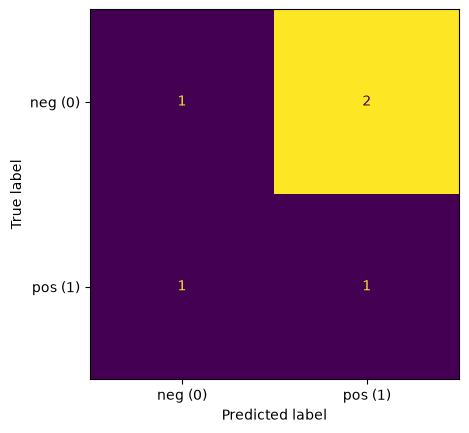

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print("Confusion matrix (rows = actual, cols = predicted):\n", cm)
print("sklearn layout for labels [0,1]:  [[TN, FP], [FN, TP]]")
ConfusionMatrixDisplay(cm, display_labels=["neg (0)", "pos (1)"]).plot(colorbar=False);

### Step 7: Visualise the decision boundary

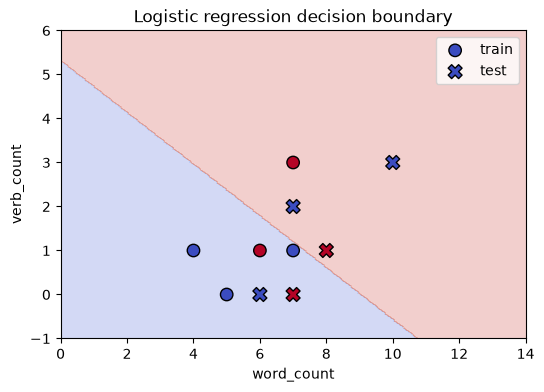

In [9]:
xx, yy = np.meshgrid(np.linspace(0, 14, 300), np.linspace(-1, 6, 300))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", marker="o", s=80, edgecolor="k", label="train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", marker="X", s=100, edgecolor="k", label="test")
plt.xlabel("word_count"); plt.ylabel("verb_count"); plt.legend(); plt.title("Logistic regression decision boundary")
plt.show()

**Why is it poor?** 5 training rows and two features (word count, verb count) that carry almost no sentiment information. Points of both colours fall in the same region, so no straight line can separate them. Better features (e.g., TF-IDF of the words themselves) fix this → see the challenge below.

In [10]:
# Challenge (beyond class): use the words themselves as features (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer()
Xtr = vec.fit_transform(train_df["review_text"])     # fit vocabulary on TRAIN only
Xte = vec.transform(test_df["review_text"])          # reuse the same vocabulary on TEST
clf = LogisticRegression().fit(Xtr, y_train)
print("TF-IDF predictions:", clf.predict(Xte), " accuracy:", accuracy_score(y_test, clf.predict(Xte)))
print("vocabulary size:", len(vec.vocabulary_))

TF-IDF predictions: [0 0 0 0 0]  accuracy: 0.6
vocabulary size: 28


TF-IDF predicts **all 0** yet scores 60%, because 3 of 5 test reviews are negative. That is the **majority-class trap**: accuracy can look decent while the model has learned nothing (→ precision/recall/F1 later). Most test words never appeared in the 5 training sentences. **Lesson:** you need more data before you need better features.

## Part B — Iris classification (supervised, multi-class)

In [11]:
import seaborn as sns
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

iris = load_iris()
X, y = iris.data, iris.target
print("shape:", X.shape, "| features:", iris.feature_names)
print("classes:", list(iris.target_names), "| counts:", np.bincount(y))
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df["species"] = pd.Categorical.from_codes(y, iris.target_names)
iris_df.head()

shape: (150, 4) | features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')] | counts: [50 50 50]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


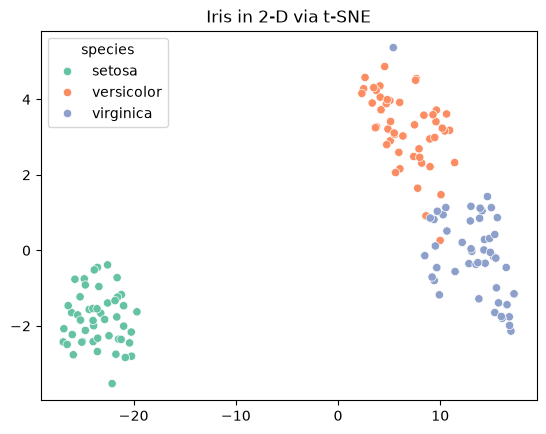

In [12]:
# 4-D data → 2-D picture with t-SNE (visualisation only; the model still uses all 4 features)
emb = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)
sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=iris_df["species"], palette="Set2")
plt.title("Iris in 2-D via t-SNE"); plt.show()

120 train / 30 test
Accuracy: 0.9333333333333333


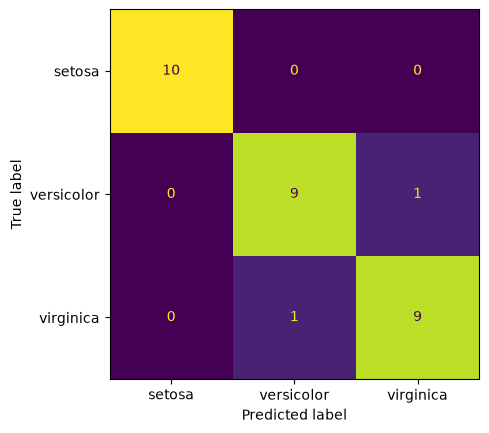

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)    # 80/20 split, reproducible, class balance kept
print(len(X_train), "train /", len(X_test), "test")

scaler = StandardScaler().fit(X_train)                     # learn mean/std from TRAIN only
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

model = LogisticRegression(max_iter=1000).fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
print("Accuracy:", accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=iris.target_names).plot(colorbar=False);

## Part C — Homework: `load_digits`
**Try it yourself first** by copying Part B and changing the loader. Things to find out: how many samples, how many features (hint: 8×8 pixels), how many classes?

Solution below.

data: (1797, 64) | images: (1797, 8, 8) | classes: [0 1 2 3 4 5 6 7 8 9]


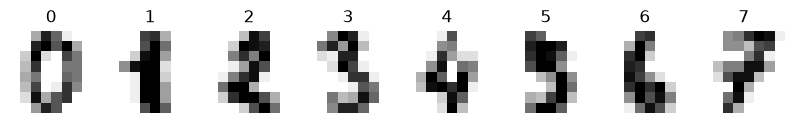

In [14]:
digits = load_digits()
print("data:", digits.data.shape, "| images:", digits.images.shape, "| classes:", digits.target_names)
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, img, t in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap="gray_r"); ax.set_title(t); ax.axis("off")
plt.show()

Accuracy: 0.9722


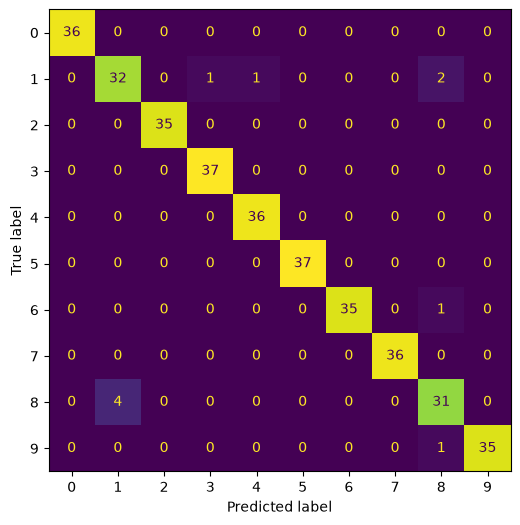

In [15]:
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(digits.data, digits.target, test_size=0.2,
                                              random_state=42, stratify=digits.target)
sc = StandardScaler().fit(Xd_tr)
clf = LogisticRegression(max_iter=2000).fit(sc.transform(Xd_tr), yd_tr)
yd_pred = clf.predict(sc.transform(Xd_te))
print("Accuracy:", round(accuracy_score(yd_te, yd_pred), 4))
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix(yd_te, yd_pred)).plot(ax=ax, colorbar=False); plt.show()

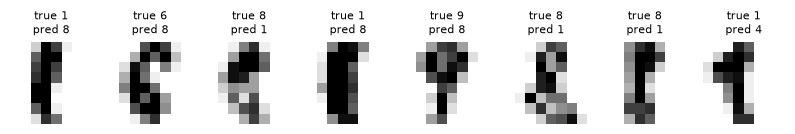

In [16]:
# Which digits did it get wrong?
wrong = np.where(yd_pred != yd_te)[0]
fig, axes = plt.subplots(1, min(8, len(wrong)), figsize=(10, 1.8))
for ax, i in zip(np.atleast_1d(axes), wrong[:8]):
    ax.imshow(Xd_te[i].reshape(8, 8), cmap="gray_r"); ax.set_title(f"true {yd_te[i]}\npred {yd_pred[i]}", fontsize=8); ax.axis("off")
plt.show()

## Part D — Extras
### D1. What does the random seed (`random_state`) do?

In [17]:
for seed in [0, 1, 42, 42]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed)
    acc = accuracy_score(yte, LogisticRegression(max_iter=1000).fit(Xtr, ytr).predict(Xte))
    print(f"seed={seed:>2}  first test row: {Xte[0].tolist()}  accuracy={acc:.3f}")

seed= 0  first test row: [5.8, 2.8, 5.1, 2.4]  accuracy=1.000
seed= 1  first test row: [5.8, 4.0, 1.2, 0.2]  accuracy=0.967
seed=42  first test row: [6.1, 2.8, 4.7, 1.2]  accuracy=1.000
seed=42  first test row: [6.1, 2.8, 4.7, 1.2]  accuracy=1.000


Same seed (42 twice) → identical split and identical accuracy. Different seed → different split → slightly different accuracy. That's why we fix the seed: **reproducibility**. Also notice that accuracy *changes with the split*, so one split is a noisy estimate (→ cross-validation later).

### D2. Pearson correlation for feature selection

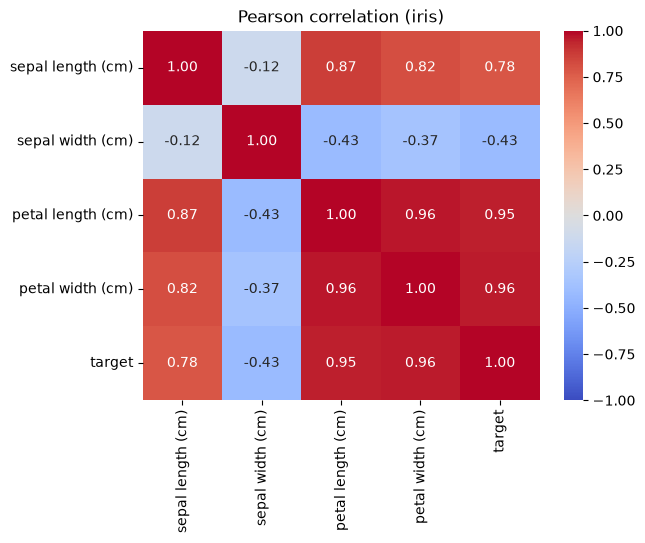

petal width (cm)     0.956547
petal length (cm)    0.949035
sepal length (cm)    0.782561
sepal width (cm)    -0.426658
Name: target, dtype: float64


In [18]:
corr = iris_df.drop(columns="species").assign(target=y).corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson correlation (iris)"); plt.show()
print(corr["target"].drop("target").sort_values(key=abs, ascending=False))

Petal length/width correlate ~0.95 with the target → most useful; sepal width is weakest. ⚠️ Pearson only captures **linear** relationships, and correlating with a *categorical* target (0/1/2) only makes sense here because the classes happen to be ordered by size.